# 제원표 배수구역 기반 하수↔도로 교차 매칭

거리(좌표) 대신 **공식 제원표의 배수구역**(같은 하수 배수단위)으로 *만관 하수 ↔ 침수 도로*를 짝지어,
시흥동 외 추가 사슬 쌍이 있는지 찾는다.

**전제 확인**: 제원표 배수구역 = 정제 노드 배수구역 100% 일치(하수·도로 모두). 노드에 배수구역 내장 → 그대로 사용.

In [1]:
import os; os.chdir('/home/namjun/city_flood')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
import sys; sys.path.insert(0,'/home/namjun/city_flood/scripts'); from krfont import set_korean; set_korean()
EB="dataset/processed/eda_based/"
sn=pd.read_parquet("dataset/processed/cleaned/sewer_node.parquet",columns=['sensor_id','지점명','배수구역','lat','lon'])
rn=pd.read_parquet("dataset/processed/cleaned/road_node.parquet",columns=['sensor_id','지점명','배수구역','lat','lon'])
au=pd.read_parquet(EB+"sewer_surcharge_audit.parquet")
trust=pd.read_parquet(EB+"road_flood_sensor_trust.parquet")
conf=au[au.최종판정.str.startswith('확정')].sewer_sensor_id.tolist()
def hav(a,b,c,d):
    R=6371000;p=np.pi/180
    x=np.sin((c-a)*p/2)**2+np.cos(a*p)*np.cos(c*p)*np.sin((d-b)*p/2)**2
    return 2*R*np.arcsin(np.sqrt(x))

## 1. 배수구역별 신호 교차표

In [2]:
sn2=sn.copy(); sn2['확정만관']=sn2.sensor_id.isin(conf)
rn2=rn.merge(trust[['sensor_id','판정_final']],on='sensor_id',how='left'); rn2['진짜상습']=rn2.판정_final=='진짜상습'
tab=[]
for z in sorted(set(sn.배수구역.dropna())|set(rn.배수구역.dropna())):
    sz=sn2[sn2.배수구역==z]; rz=rn2[rn2.배수구역==z]
    tab.append([z,len(sz),int(sz.확정만관.sum()),len(rz),int(rz.진짜상습.sum())])
T=pd.DataFrame(tab,columns=['배수구역','하수','확정만관','도로','진짜상습'])
print(T.to_string(index=False))
both=T[(T.확정만관>0)&(T.진짜상습>0)]
print("\n둘 다 있는 구역:",both.배수구역.tolist())
print("진짜상습 도로 있으나 확정만관 0인 구역:",T[(T.진짜상습>0)&(T.확정만관==0)].배수구역.tolist())

배수구역  하수  확정만관  도로  진짜상습
  강서  15     1   1     0
 노량진  13     0   3     0
  뚝도  10     0   4     0
  마포  23     0   6     1
  망원   9     0   3     0
  반포 110     0  14     1
  불광  16     0   3     1
  성내  22     0  10     0
 안양천  98     2  35     3
  용산   4     0   2     0
  욱천   7     0   4     0
  중랑  49     1  10     1
  청계  36     1  10     0
  탄천  71     0   6     0
  홍제   1     0   2     1

둘 다 있는 구역: ['안양천', '중랑']
진짜상습 도로 있으나 확정만관 0인 구역: ['마포', '반포', '불광', '홍제']


## 2. 진짜상습 도로 10곳 → 최근접 확정만관 하수 거리

In [3]:
real=rn.merge(trust[trust.판정_final=='진짜상습'][['sensor_id']],on='sensor_id',how='inner')
sc=sn[sn.sensor_id.isin(conf)]
rows=[]
for _,r in real.iterrows():
    if pd.isna(r.lat): rows.append([r.sensor_id,r.배수구역,None,np.nan,False]); continue
    d=hav(r.lat,r.lon,sc.lat.values,sc.lon.values); i=int(d.argmin())
    rows.append([r.sensor_id,r.배수구역,sc.iloc[i].sensor_id,float(d[i]),sc.iloc[i].배수구역==r.배수구역])
D=pd.DataFrame(rows,columns=['도로','배수구역','최근접확정만관','거리m','같은구역']).sort_values('거리m')
print(D.to_string(index=False))
print(f"\n575m 이내(사슬 검증가능): {(D.거리m<=600).sum()}곳 → 시흥동 882-61 뿐")

        도로 배수구역 최근접확정만관         거리m  같은구역
시흥동 882-61  안양천 18-0018  574.656471  True
   조원로 5-6  안양천 18-0018 3669.651561  True
 대림동 862-5  안양천 20-0012 4497.760535  True
 중곡동 637-4   중랑 06-0009 4763.723094 False
   신영동 165   홍제 06-0009 6794.583983 False
성산로 494-30   마포 20-0012 7082.902426 False
역삼동 829-15   반포 20-0012 7115.504315 False
 갈현동 466-9   불광 16-0017 9172.759246 False
 사당2동 86-9  NaN     NaN         NaN False
하월곡동 226-8  NaN     NaN         NaN False

575m 이내(사슬 검증가능): 1곳 → 시흥동 882-61 뿐


## 3. 시각화

/tmp/ipykernel_277925/2325707371.py:16: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('reports/figures_sewer/07_zone_matching.png',dpi=110,bbox_inches='tight'); plt.show()
/tmp/ipykernel_277925/2325707371.py:16: UserWarning: Glyph 49436 (\N{HANGUL SYLLABLE SEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('reports/figures_sewer/07_zone_matching.png',dpi=110,bbox_inches='tight'); plt.show()
/tmp/ipykernel_277925/2325707371.py:16: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('reports/figures_sewer/07_zone_matching.png',dpi=110,bbox_inches='tight'); plt.show()
/tmp/ipykernel_277925/2325707371.py:16: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig('reports/figures_sewer/07_zone_matching.png',dpi=110,bbox_inches='tight'); plt.show()
/tmp/ipykernel_277925

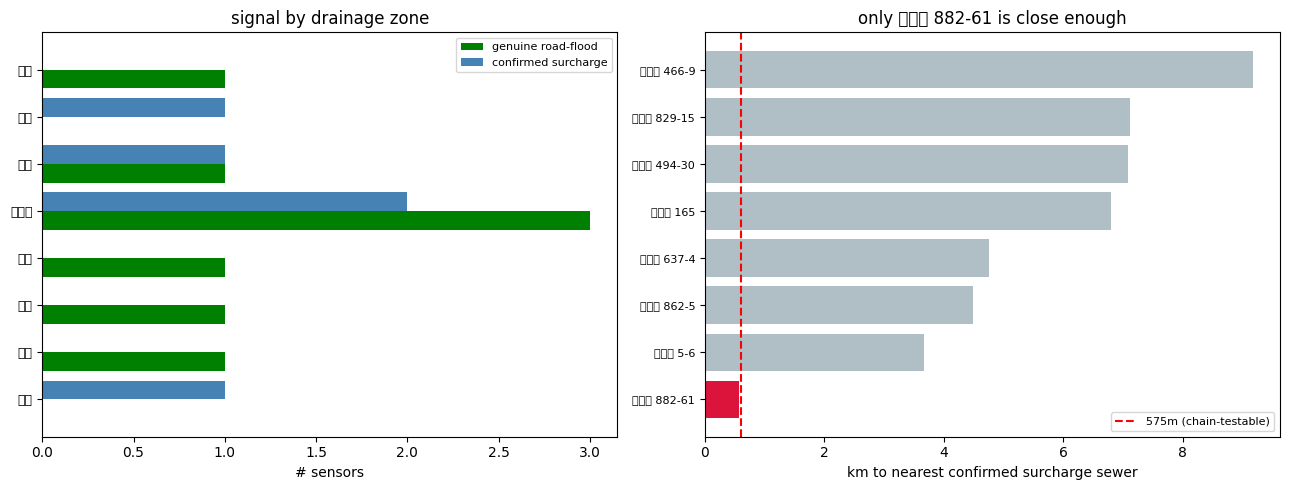

saved


In [4]:
fig,ax=plt.subplots(1,2,figsize=(13,5))
# (A) 배수구역 신호
T2=T[(T.진짜상습>0)|(T.확정만관>0)]
y=np.arange(len(T2))
ax[0].barh(y-0.2,T2.진짜상습,0.4,label='진짜 도로침수',color='green')
ax[0].barh(y+0.2,T2.확정만관,0.4,label='확정 만관',color='steelblue')
ax[0].set_yticks(y); ax[0].set_yticklabels(T2.배수구역,fontsize=9)
ax[0].set_xlabel('센서 수'); ax[0].set_title('배수구역별 신호'); ax[0].legend(fontsize=8)
# (B) 도로->최근접 확정만관 거리
Dv=D.dropna(subset=['거리m']).sort_values('거리m')
cols=['crimson' if d<=600 else '#b0bec5' for d in Dv.거리m]
ax[1].barh(np.arange(len(Dv)),Dv.거리m/1000,color=cols)
ax[1].axvline(0.6,ls='--',c='red',label='575m (사슬 검증가능)')
ax[1].set_yticks(np.arange(len(Dv))); ax[1].set_yticklabels(Dv.도로,fontsize=8)
ax[1].set_xlabel('최근접 확정만관 하수까지 거리(km)'); ax[1].set_title('575m 이내는 시흥동 882-61 뿐'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig('reports/figures_sewer/07_zone_matching.png',dpi=110,bbox_inches='tight'); plt.show()
D.to_parquet(EB+"road_surcharge_zone_pairing.parquet",index=False)
print('saved')

## 결론
- **배수구역 매칭으로도 시흥동 외 새 사슬 쌍은 안 나온다.** 진짜상습 도로 10곳 중 확정만관 하수와 575m 이내는 **시흥동 882-61 단 1곳**, 나머지는 3.6~9.2km 이격.
- 원인: 공식 **배수구역이 15개 거대 basin**으로 너무 coarse(안양천 하나에 하수98·도로35). 같은 구역이어도 수 km 떨어진 다른 소배수구역. → GNN 엣지/페어링 단위로 부적합, **소배수구역(세부 관망) 토폴로지 필요**.
- 부수 발견: **마포·반포·불광·홍제는 진짜상습 도로 침수가 있으나 확정만관 하수 0** = 하수 만관 없이 침수(표면류형). 관악 결론과 일치 — *침수≠하수만관*인 지역이 다수.